### Data Creation

In [3]:
import os
from dotenv import load_dotenv
load_dotenv('../env')

True

In [45]:
! pip install -U openai, langchain, langchain_openai

  Using cached tiktoken-0.8.0-cp312-cp312-win_amd64.whl.metadata (6.8 kB)
Using cached tiktoken-0.8.0-cp312-cp312-win_amd64.whl (883 kB)


In [5]:
from langchain_core.prompts import ChatPromptTemplate
from pydantic import BaseModel, Field
from langchain_openai import ChatOpenAI
from langchain_core.output_parsers import StrOutputParser

from langchain_core.output_parsers import PydanticOutputParser
from langchain_core.prompts import PromptTemplate

import pandas as pd

In [39]:
# Define the output schema.
class OPTemplate(BaseModel):
    INFJ: int
    INFP: int
    ENFP: int
    ISFP: int
    ENFJ: int
    INTP: int
    ENTP: int
    INTJ: int
    ISFJ: int
    ISTP: int
    ESTP: int
    ESFP: int
    ISTJ: int
    ESFJ: int
    ENTJ: int
    ESTJ: int

# Create the output parser.
parser = PydanticOutputParser(pydantic_object=OPTemplate)

# Define the system and human prompts.
overall_system_prompt = "You are a helpful assistant."

overall_human_prompt = (
    "For each provided Myers-Briggs personality type, assign a rating between 1 and 10 for the likelihood of engaging with the following quote (1 = very unlikely, 10 = highly likely).\n\n"
    "Quote:\n"
    "------------\n"
    "{quote}\n"
    "------------\n"
)

# Build the ChatPromptTemplate and insert format_instructions from the parser.
prompt = ChatPromptTemplate(
    messages=[
        ("system", overall_system_prompt),
        ("human", overall_human_prompt + "\n{format_instructions}")
    ]
).partial(format_instructions=parser.get_format_instructions())

# Invoke the prompt with an actual quote.
result = prompt.invoke(input={"quote": "Your inspirational quote goes here."})
print(result)


messages=[SystemMessage(content='You are a helpful assistant.', additional_kwargs={}, response_metadata={}), HumanMessage(content='For each provided Myers-Briggs personality type, assign a rating between 1 and 10 for the likelihood of engaging with the following quote (1 = very unlikely, 10 = highly likely).\n\nQuote:\n------------\nYour inspirational quote goes here.\n------------\n\nThe output should be formatted as a JSON instance that conforms to the JSON schema below.\n\nAs an example, for the schema {"properties": {"foo": {"title": "Foo", "description": "a list of strings", "type": "array", "items": {"type": "string"}}}, "required": ["foo"]}\nthe object {"foo": ["bar", "baz"]} is a well-formatted instance of the schema. The object {"properties": {"foo": ["bar", "baz"]}} is not well-formatted.\n\nHere is the output schema:\n```\n{"properties": {"INFJ": {"title": "Infj", "type": "integer"}, "INFP": {"title": "Infp", "type": "integer"}, "ENFP": {"title": "Enfp", "type": "integer"}, 

In [61]:
model = ChatOpenAI(model="gpt-4o-mini")
chain = prompt | model | StrOutputParser()

In [69]:
resp = chain.invoke(input={"quote": "Some individuals have the courage to make it, even feel the need to do so; for them the quest is a necessity, not an option. Most people setting out on such journeys are never heard from again, but part of the romance of any field lies in keeping the dream alive, in not settling for what is familiar and comfortable."})
print(resp)

```json
{
  "INFJ": 9,
  "INFP": 10,
  "ENFP": 10,
  "ISFP": 8,
  "ENFJ": 9,
  "INTP": 7,
  "ENTP": 8,
  "INTJ": 9,
  "ISFJ": 6,
  "ISTP": 5,
  "ESTP": 6,
  "ESFP": 7,
  "ISTJ": 4,
  "ESFJ": 5,
  "ENTJ": 8,
  "ESTJ": 5
}
```


In [75]:
#cost estimation
10000 * 1000 * 0.075 / 10**6 * 2 * 2

0.75

In [102]:
data = pd.read_csv('../data/sampled_quotes.csv')
data.drop(columns='Unnamed: 0', inplace=True)

In [104]:
data.head()

,quote,author,category,quote_norm
0,The sting of her abandonment had not lessened ...,"T.J. Forrester, Miracles, Inc.: A Novel","love, relationship, suffering",The sting of her abandonment had not lessened ...
1,Everything that falls upon the eye is an appar...,Marilynn Robinson in Housekeeping,"grief, loss, memory, remembering-the-good, time",Everything that falls upon the eye is an appar...
2,I don't hate Republicans as individuals. But I...,Howard Dean,"politics, republicans",I do not hate Republicans as individuals. But ...
3,Think More Not Less.,Jelani Payne,"critical-thinking, perspective",Think More Not Less.
4,"Some individuals have the courage to make it, ...","Gino Segrè, Ordinary Geniuses: Max Delbruck, G...","comfortable, dream, inspirational, journey, jo...","Some individuals have the courage to make it, ..."


In [128]:
data['quote_combined'] = data['quote'] + ' \n- ' + data['author']
print(data['quote_combined'][0])

The sting of her abandonment had not lessened through the years, and I suspected it would never go away. Occasionally, I could see agony in her eyes, the shadows that flickered in the background. If I could, I'd take her pain and make it my own. I'd swallow it like a bitter pill and live with the consequences. 
- T.J. Forrester, Miracles, Inc.: A Novel


In [154]:
ratings_raw = {}
error_idx = []
for idx, row in data.iterrows():
    try:
        ratings_raw[idx] = chain.invoke(input={"quote": row['quote_combined']})
    except Exception as e:
        error_idx.append(idx)
        print(f"Error at index {idx}: {e}")

In [172]:
len(error_idx)

0

In [160]:
import json

with open("ratings_raw.json", "w") as f:
    json.dump(ratings_raw, f, indent=4)  # Pretty print with indentation

In [174]:
import re

ratings = {}
error_idx2 = []
for k,v in ratings_raw.items():
    match = re.search(r"{.*}", v, re.DOTALL)
    if match:
        json_str = match.group(0)
        ratings[k] = json.loads(json_str)
    else:
        error_idx.append(k)

In [180]:
with open("ratings.json", "w") as f:
    json.dump(ratings, f, indent=4)  # Pretty print with indentation

In [182]:
len(error_idx2)

0

In [193]:
user_id_map = {}
for i,persona in enumerate(list(ratings[0].keys())):
    user_id_map[persona] = i
user_id_map

{'INFJ': 0,
 'INFP': 1,
 'ENFP': 2,
 'ISFP': 3,
 'ENFJ': 4,
 'INTP': 5,
 'ENTP': 6,
 'INTJ': 7,
 'ISFJ': 8,
 'ISTP': 9,
 'ESTP': 10,
 'ESFP': 11,
 'ISTJ': 12,
 'ESFJ': 13,
 'ENTJ': 14,
 'ESTJ': 15}

In [489]:
id_persona_map = {}
for k,v in user_id_map.items():
    id_persona_map[v] = k

In [279]:
interaction_dataset = []
for idx,r_dict in ratings.items():
    for k,v in r_dict.items():
        interaction_dataset.append(
            {
                'user_id' : user_id_map[k],
                'quote_id':idx,
                'liked' : v/10
            }
        )

In [281]:
int_data  = pd.DataFrame(interaction_dataset) 

In [287]:
int_data.head()

,user_id,quote_id,liked
0,0,0,0.9
1,1,0,1.0
2,2,0,0.8
3,3,0,0.8
4,4,0,0.9


In [283]:
int_data.to_csv('../data/simulated_interactions.csv')

In [7]:
int_data = pd.read_csv('../data/simulated_interactions.csv')
int_data.drop(columns=["Unnamed: 0"], inplace=True)
int_data.head()

,user_id,quote_id,liked
0,0,0,0.9
1,1,0,1.0
2,2,0,0.8
3,3,0,0.8
4,4,0,0.9


In [9]:
int_data['liked'].value_counts()

liked
0.8    27188
0.5    23681
0.9    23664
0.6    23386
0.7    22755
0.4    18501
1.0     9629
0.3     8909
0.2     1995
0.1      292
Name: count, dtype: int64

In [251]:
10**4 * 33293 / 16000

20808.125

### Pre-Training

In [11]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
import numpy as np

In [13]:
class UserTower(nn.Module):
    def __init__(self):
        super().__init__()
        # 128 > 64 > 32
        self.embedding = nn.Embedding(200, 128)
        self.mlp = nn.Sequential(
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
        )
        
    def forward(self, user_ids):
        return self.mlp(self.embedding(user_ids))

In [15]:
class QuoteTower(nn.Module):
    def __init__(self, num_quote_ids=10000):
        super().__init__()
        
        # Dynamic content-aware embedding based on quote id
        self.dynamic_embed = nn.Embedding(num_quote_ids, 128)
        
        self.dynamic_fc = nn.Sequential(
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 32)
        )

        # Load static author embeddings
        self.author_embed = nn.Embedding(num_quote_ids, 384)
        self.author_embed.load_state_dict(torch.load('../models/author_embeddings.pth'))
        self.author_embed.weight.requires_grad = False  # Keep embeddings frozen

        self.author_fc =  nn.Sequential(
            nn.Linear(384, 256),
            nn.ReLU(),
            nn.Linear(256, 128)
        )
        
        # Load static quote embeddings
        self.quote_embed = nn.Embedding(num_quote_ids, 384)
        self.quote_embed.load_state_dict(torch.load('../models/quote_embeddings.pth'))
        self.quote_embed.weight.requires_grad = False  # Keep embeddings frozen

        self.quote_fc =  nn.Sequential(
            nn.Linear(384, 256),
            nn.ReLU(),
            nn.Linear(256, 128)
        )
        
        # Combined MLP processing. The concatenated features are:
        # - Adjusted static quote embedding: 64
        # - Dynamic quote id embedding: 32
        # - Static author embedding: author_embedding_dim
        combined_dim = 128*2 + 32
        self.mlp = nn.Sequential(
            nn.Linear(combined_dim, 512),
            nn.ReLU(),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
        )

    def forward(self, quote_ids):
        """
        Args:
            quote_ids (Tensor): Quote ID indices (batch_size,)
        
        Returns:
            Tensor: Output features (batch_size, 128)
        """
        # Retrieve frozen static quote embedding and process it
        static_quote = self.quote_embed(quote_ids)  # (batch_size, 384)
        static_quote = self.quote_fc(static_quote)  # (batch_size, 128)
    
        # Retrieve frozen static author embedding and process it
        static_author = self.author_embed(quote_ids)  # (batch_size, 384)
        static_author = self.author_fc(static_author)  # (batch_size, 128)
    
        # Retrieve dynamic quote embedding and process it
        dynamic_quote = self.dynamic_embed(quote_ids)  # (batch_size, 512)
        dynamic_quote = self.dynamic_fc(dynamic_quote)  # (batch_size, 128)
    
        # Concatenate all features (128 + 128 + 128 = 384)
        combined = torch.cat([static_quote, static_author, dynamic_quote], dim=1)
    
        # Process through MLP
        return self.mlp(combined)  # (batch_size, 128)

In [17]:
class TwoTowerModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.user_tower = UserTower()
        self.quote_tower = QuoteTower()
        
    def forward(self, user_ids, quote_ids):
        user_embeds = self.user_tower(user_ids)
        quote_embeds = self.quote_tower(quote_ids)
        return (user_embeds * quote_embeds).sum(dim=1)  # Dot product

In [19]:
class InteractionDataset(Dataset):
    def __init__(self, dataframe):
        """
        Args:
            dataframe (pd.DataFrame): DataFrame with columns 'user_id', 'quote_id', 'liked'
        """
        self.df = dataframe.reset_index(drop=True)
    
    def __len__(self):
        return len(self.df)
    
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        # Convert to tensors: user_id and quote_id are indices (long); liked is a continuous float value.
        user_id = torch.tensor(int(row['user_id']), dtype=torch.long)
        quote_id = torch.tensor(int(row['quote_id']), dtype=torch.long)
        liked = torch.tensor(float(row['liked']), dtype=torch.float)
        return user_id, quote_id, liked

In [21]:
generator = torch.Generator().manual_seed(42)

In [23]:
full_dataset = InteractionDataset(int_data)

total_size = len(full_dataset)
train_size = int(0.8 * total_size)
val_size = total_size - train_size
train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size],generator=generator)

# Create DataLoaders
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False)

In [25]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = TwoTowerModel().to(device)
criterion = nn.MSELoss()  # Using MSE loss for continuous labels during training
optimizer = optim.Adam(model.parameters(), lr=1e-3,weight_decay=1e-5)
num_epochs = 20
divergence_ratio_threshold = 1.15

In [27]:
for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    for user_ids, quote_ids, liked in train_loader:
        user_ids = user_ids.to(device)
        quote_ids = quote_ids.to(device)
        liked = liked.to(device)
        
        optimizer.zero_grad()
        outputs = model(user_ids, quote_ids)  # (batch_size,)
        loss = criterion(outputs, liked)
        weights = torch.where(liked == 0.8, torch.tensor(0.5, device=liked.device), torch.tensor(1.0, device=liked.device))
        weighted_loss = (loss * weights).mean()
        weighted_loss.backward()
        # loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * user_ids.size(0)
    
    avg_train_loss = running_loss / len(train_dataset)
    print(f"Epoch {epoch+1}/{num_epochs} - Train Loss: {avg_train_loss:.4f}")
    
    # Every 1 epochs, evaluate on the validation set.
    if (epoch + 1) % 1 == 0:
        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for user_ids, quote_ids, liked in val_loader:
                user_ids = user_ids.to(device)
                quote_ids = quote_ids.to(device)
                liked = liked.to(device)
                
                outputs = model(user_ids, quote_ids)
                loss = criterion(outputs, liked)
                val_loss += loss.item() * user_ids.size(0)
                
        avg_val_loss = val_loss / len(val_dataset)
        print(f"Epoch {epoch+1}/{num_epochs} - Validation Loss: {avg_val_loss:.4f}")
        
        # Check if the validation loss diverges too much from the training loss.
        if avg_val_loss / avg_train_loss > divergence_ratio_threshold:
            print(f"Validation loss is {avg_val_loss/avg_train_loss:.2f} times the training loss. Stopping early.")
            break

Epoch 1/20 - Train Loss: 0.0224
Epoch 1/20 - Validation Loss: 0.0203
Epoch 2/20 - Train Loss: 0.0194
Epoch 2/20 - Validation Loss: 0.0188
Epoch 3/20 - Train Loss: 0.0168
Epoch 3/20 - Validation Loss: 0.0155
Epoch 4/20 - Train Loss: 0.0138
Epoch 4/20 - Validation Loss: 0.0136
Epoch 5/20 - Train Loss: 0.0124
Epoch 5/20 - Validation Loss: 0.0134
Epoch 6/20 - Train Loss: 0.0114
Epoch 6/20 - Validation Loss: 0.0118
Epoch 7/20 - Train Loss: 0.0108
Epoch 7/20 - Validation Loss: 0.0115
Epoch 8/20 - Train Loss: 0.0105
Epoch 8/20 - Validation Loss: 0.0112
Epoch 9/20 - Train Loss: 0.0103
Epoch 9/20 - Validation Loss: 0.0115
Epoch 10/20 - Train Loss: 0.0101
Epoch 10/20 - Validation Loss: 0.0111
Epoch 11/20 - Train Loss: 0.0100
Epoch 11/20 - Validation Loss: 0.0108


KeyboardInterrupt: 

In [57]:
torch.save(model.state_dict(), "../models/two_tower.pth")

##### Freezing Quote Tower & Precomputing Quote Embeddings

In [31]:
# Freeze the quote tower's parameters
for param in model.quote_tower.parameters():
    param.requires_grad = False

# Set the quote tower to evaluation mode
model.quote_tower.eval()

QuoteTower(
  (dynamic_embed): Embedding(10000, 128)
  (dynamic_fc): Sequential(
    (0): Linear(in_features=128, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=32, bias=True)
  )
  (author_embed): Embedding(10000, 384)
  (author_fc): Sequential(
    (0): Linear(in_features=384, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=128, bias=True)
  )
  (quote_embed): Embedding(10000, 384)
  (quote_fc): Sequential(
    (0): Linear(in_features=384, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=128, bias=True)
  )
  (mlp): Sequential(
    (0): Linear(in_features=288, out_features=512, bias=True)
    (1): ReLU()
    (2): Linear(in_features=512, out_features=256, bias=True)
    (3): ReLU()
    (4): Linear(in_features=256, out_features=128, bias=True)
    (5): ReLU()
    (6): Linear(in_features=128, out_features=64, bias=True)
    (7): ReLU()
    (8): Linear(in_feature

In [33]:
import torch

# Assume you have num_quote_ids quotes (adjust as needed)
num_quote_ids = 10000

# Create a tensor with all quote IDs (0 to num_quote_ids - 1)
all_quote_ids = torch.arange(num_quote_ids, dtype=torch.long).to(device)

# Precompute the embeddings
with torch.no_grad():
    precomputed_quote_embeds = model.quote_tower(all_quote_ids)  # Shape: (num_quote_ids, embedding_dim)

# Optionally, move the embeddings to CPU and detach for storage/fast lookup
precomputed_quote_embeds = precomputed_quote_embeds.detach().cpu()

In [35]:
torch.save(precomputed_quote_embeds, "../models/trained_quote_embeds.pth")

In [37]:
trained_user_tower = model.user_tower

In [39]:
class UserRecommender(nn.Module):
    def __init__(self,precomputed_quote_embeds,trained_user_tower):
        """
        Args:
            precomputed_quote_embeds (Tensor): Precomputed quote embeddings of shape (num_quotes, embedding_dim)
        """
        super().__init__()
        self.user_tower = trained_user_tower  # Trainable user tower.
        # Register precomputed quote embeddings as a buffer so they are not updated during training.
        self.register_buffer('quote_embeds', precomputed_quote_embeds)
    
    def forward(self, user_ids, quote_ids):
        """
        Args:
            user_ids (Tensor): User IDs of shape (batch_size,)
            quote_ids (Tensor): Quote IDs of shape (batch_size,)
        
        Returns:
            scores (Tensor): Dot product scores of shape (batch_size,)
        """
        # Compute user embeddings using the trainable user tower.
        user_embeds = self.user_tower(user_ids)  # (batch_size, embedding_dim)
        # Retrieve fixed quote embeddings using the provided quote IDs.
        quote_embeds = self.quote_embeds[quote_ids]  # (batch_size, embedding_dim)
        # Compute dot product similarity.
        scores = (user_embeds * quote_embeds).sum(dim=1)
        return scores


In [41]:
prod_model = UserRecommender(precomputed_quote_embeds,trained_user_tower)
prod_model.eval()

UserRecommender(
  (user_tower): UserTower(
    (embedding): Embedding(200, 128)
    (mlp): Sequential(
      (0): Linear(in_features=128, out_features=64, bias=True)
      (1): ReLU()
      (2): Linear(in_features=64, out_features=32, bias=True)
    )
  )
)

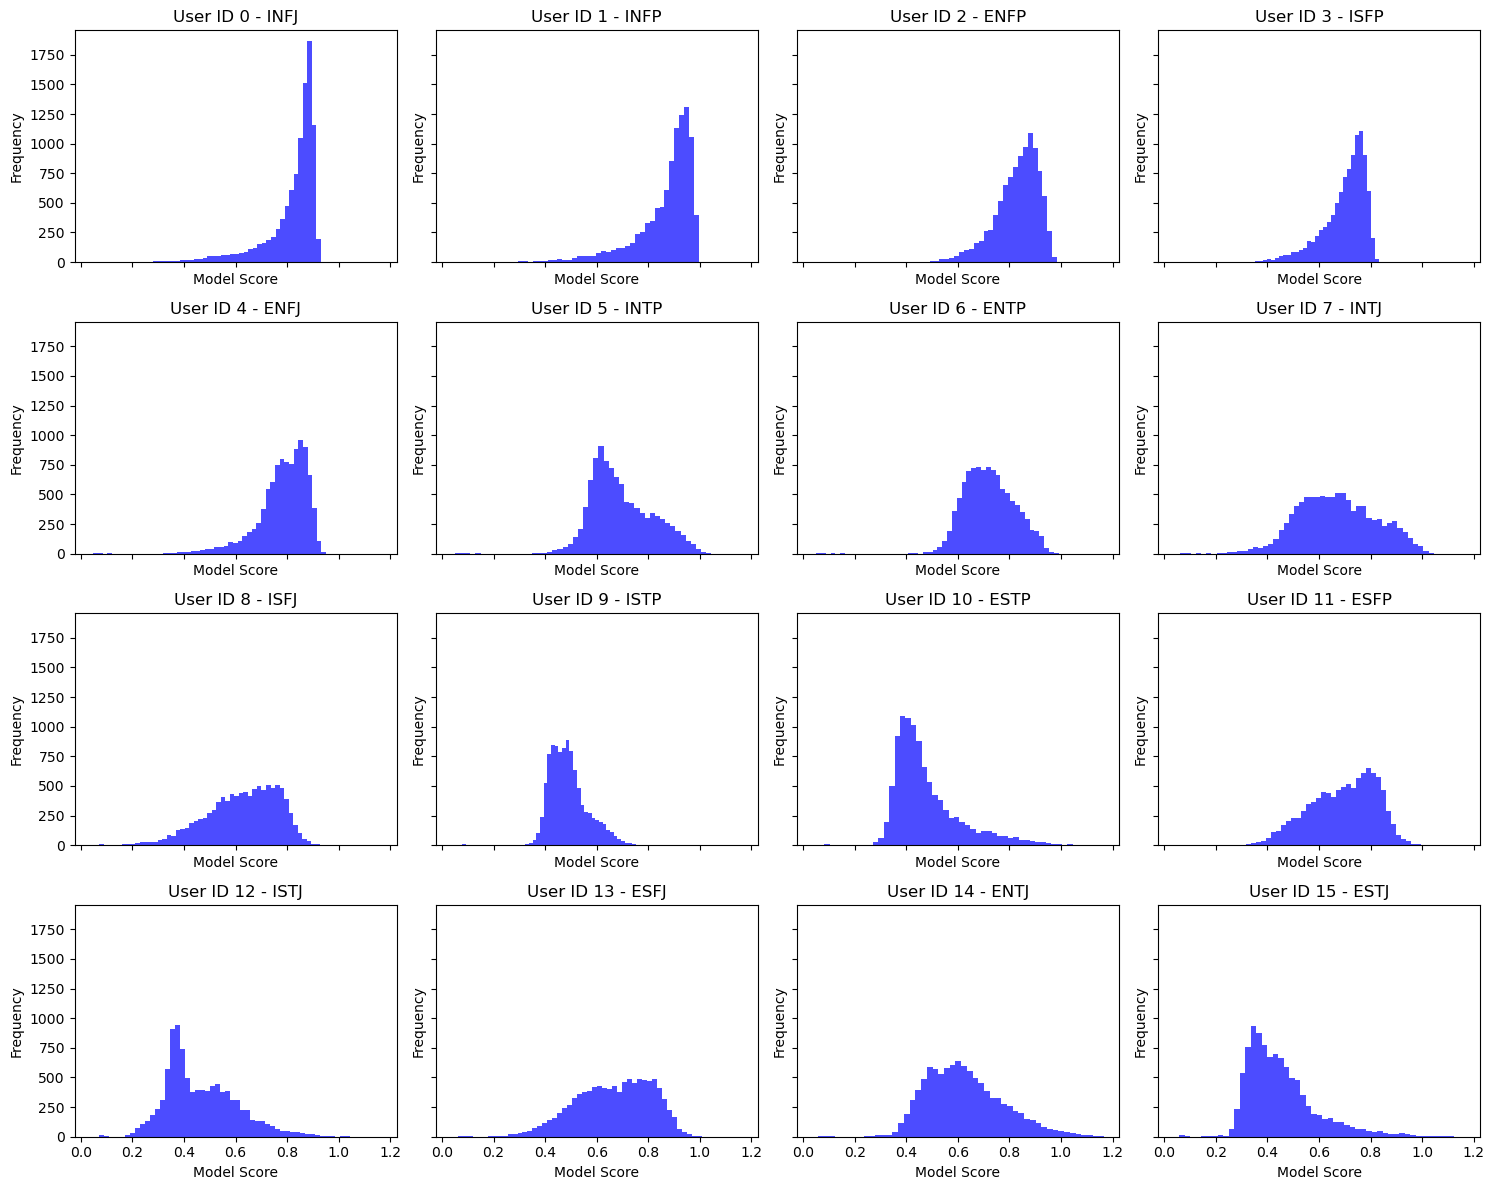

In [493]:
# Get user IDs 0 to 15
user_ids = torch.arange(0, 16, dtype=torch.long).to(device)

# Compute user embeddings (shape: [16, embedding_dim])
with torch.no_grad():
    user_embeds = prod_model.user_tower(user_ids)

# Prepare a subplot grid for histograms (4x4 grid for 16 users)
fig, axes = plt.subplots(4, 4, figsize=(15, 12), sharex=True, sharey=True)
axes = axes.flatten()

# For each user, compute dot product scores with all quote embeddings and plot the histogram
for i in range(user_embeds.shape[0]):
    # Compute scores: dot product between user embedding and every quote embedding
    # Shape of scores: [num_quotes]
    scores = torch.matmul(user_embeds[i], precomputed_quote_embeds.t())
    
    # Convert scores to a NumPy array for plotting
    scores_np = scores.cpu().numpy()
    
    # Plot a histogram for this user's scores
    ax = axes[i]
    ax.hist(scores_np, bins=50, color='blue', alpha=0.7)
    ax.set_title(f'User ID {i} - {id_persona_map[i]}')
    ax.set_xlabel('Model Score')
    ax.set_ylabel('Frequency')

plt.tight_layout()
plt.show()

In [43]:
# Assuming `user_tower` is an instance of `UserTower`
embedding_layer = prod_model.user_tower.embedding

# Extract the embedding weights
embedding_weights = embedding_layer.weight.data  # Shape: (200, 128)

In [45]:
torch.norm(embedding_weights[:16],dim=1)

tensor([1.0027, 1.2884, 1.0599, 0.6595, 1.1569, 0.7436, 0.7071, 0.7498, 0.6805,
        0.5736, 0.7042, 1.0563, 0.7431, 1.1203, 0.8453, 0.8837])

In [47]:
# Compute the average of the first 16 embeddings
average_embedding = embedding_weights[:16].mean(dim=0)  # Shape: (128,)

# Update all embeddings (indices 16 and onward) with the average embedding
embedding_weights[16:] = average_embedding

# Reassign the updated weights back to the embedding layer (optional, for clarity)
prod_model.user_tower.embedding.weight.data = embedding_weights

print("Updated embedding weights based on the average of the first 16 embeddings.")

Updated embedding weights based on the average of the first 16 embeddings.


In [55]:
torch.save(prod_model.state_dict(), "../models/base_prod_model.pth")

#### Visualize User Embeddings

In [421]:
import torch
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

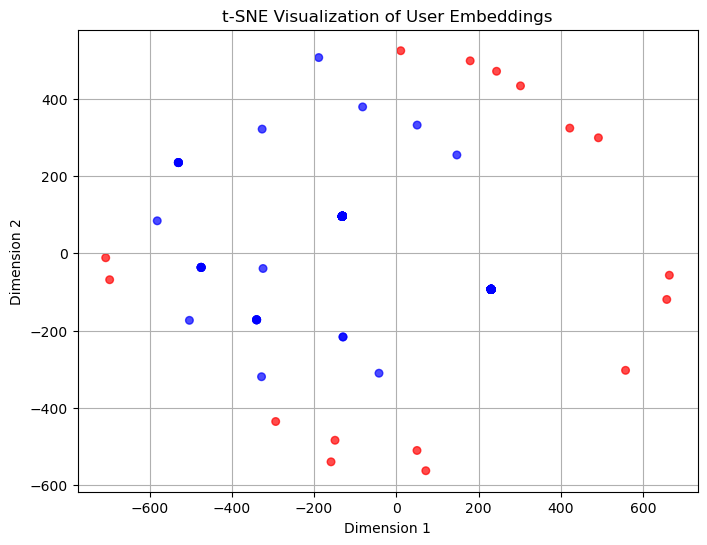

In [425]:
# Assume `model` is your TwoTowerModel instance and it's on the appropriate device.
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.eval()  # Set model to evaluation mode.

# Define the number of users you want to visualize.
num_users = 200  # Adjust based on your actual user count
user_ids = torch.arange(0, num_users, dtype=torch.long).to(device)

with torch.no_grad():
    # Option: Visualize final user embeddings (after the MLP and normalization)
    user_embeds = model.user_tower(user_ids)  # Shape: (num_users, embedding_dim)
    # If you want the raw embeddings, you could use:
    # user_embeds = model.user_tower.embedding.weight.data

# Move embeddings to CPU and convert to numpy array
user_embeds_np = user_embeds.cpu().numpy()

# Use t-SNE to reduce dimensions to 2D
tsne = TSNE(n_components=2, random_state=42)
user_embeds_2d = tsne.fit_transform(user_embeds_np)

# Create a list of colors: first 16 embeddings in red, the rest in blue.
colors = ['red' if i < 16 else 'blue' for i in range(num_users)]

# Plot the 2D embeddings using matplotlib
plt.figure(figsize=(8, 6))
plt.scatter(user_embeds_2d[:, 0], user_embeds_2d[:, 1], c=colors, s=30, alpha=0.7)
plt.title('t-SNE Visualization of User Embeddings')
plt.xlabel('Dimension 1')
plt.ylabel('Dimension 2')
plt.grid(True)
plt.show()


#### Visualize Quote Embeddings

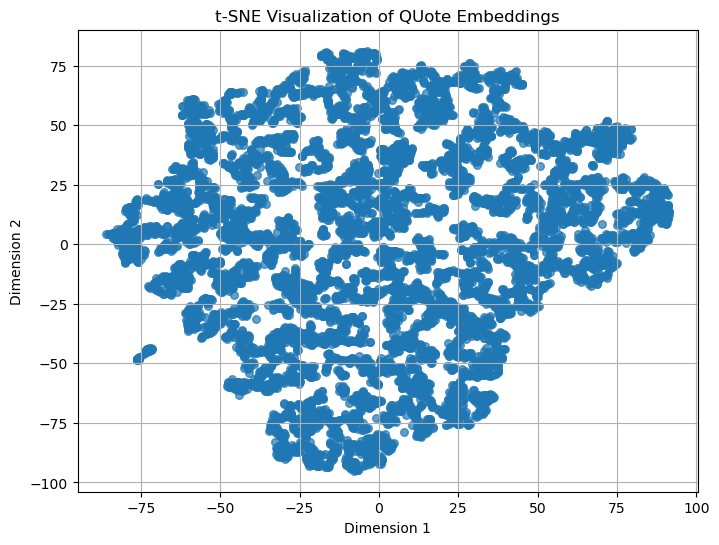

In [432]:
# Assume `model` is your TwoTowerModel instance and it's already on the appropriate device.
# Also assume your UserTower is defined to handle 'num_users' users, e.g., 200.

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.eval()  # Set model to evaluation mode.

# Define the number of users you want to visualize.
# This could be the full range of your user ids.
num_quotes = 10000  # Adjust as necessary
quote_ids = torch.arange(0, num_quotes, dtype=torch.long).to(device)

with torch.no_grad():
    # Option 1: Visualize final user embeddings (after MLP and LayerNorm)
    quote_embeds = model.quote_tower(quote_ids)  # Shape: (num_users, embedding_dim)
    
    # Option 2 (if desired): Visualize raw embedding table from the embedding layer.
    # Uncomment the next line if you want to visualize the raw embeddings.
    # user_embeds = model.user_tower.embedding.weight.data

# Move embeddings to CPU and convert to numpy
quote_embeds_np = quote_embeds.cpu().numpy()

# Reduce dimensions to 2D using t-SNE
tsne = TSNE(n_components=2, random_state=42)
quote_embeds_2d = tsne.fit_transform(quote_embeds_np)

# Plot the 2D embeddings using matplotlib
plt.figure(figsize=(8, 6))
plt.scatter(quote_embeds_2d[:, 0], quote_embeds_2d[:, 1], s=30, alpha=0.7)
plt.title('t-SNE Visualization of Quote Embeddings')
plt.xlabel('Dimension 1')
plt.ylabel('Dimension 2')
plt.grid(True)
plt.show()
